## Problem Statement
Predict which customers will churn so the company
can retain them before they leave.

### Imports & Setup

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
import joblib

### Load dataset

In [33]:
df = pd.read_csv(r'C:\Users\Hasnain Arain\Downloads\customer_churn\Customer-Churn.csv')
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## EDA

#### basic info

In [34]:
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
print("\nChurn Distribution:\n", df['Churn'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#### churn class distribution

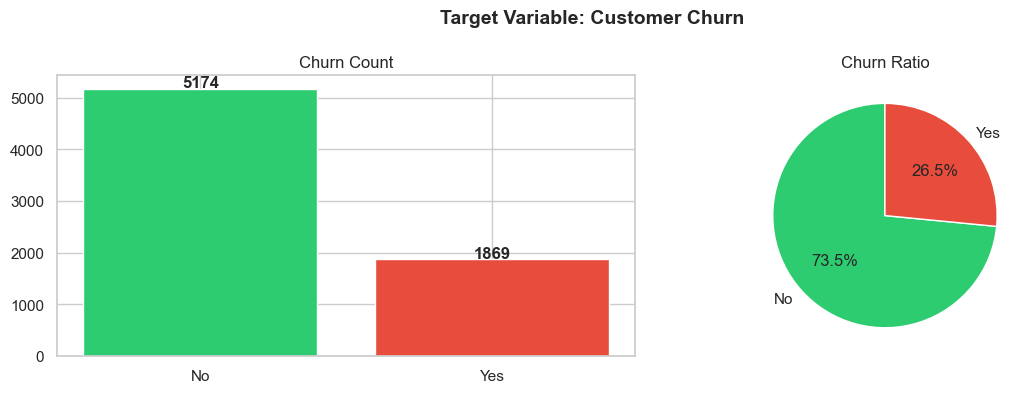

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[0].set_title('Churn Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Churn Ratio')
plt.suptitle('Target Variable: Customer Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Numerical distributions by churn

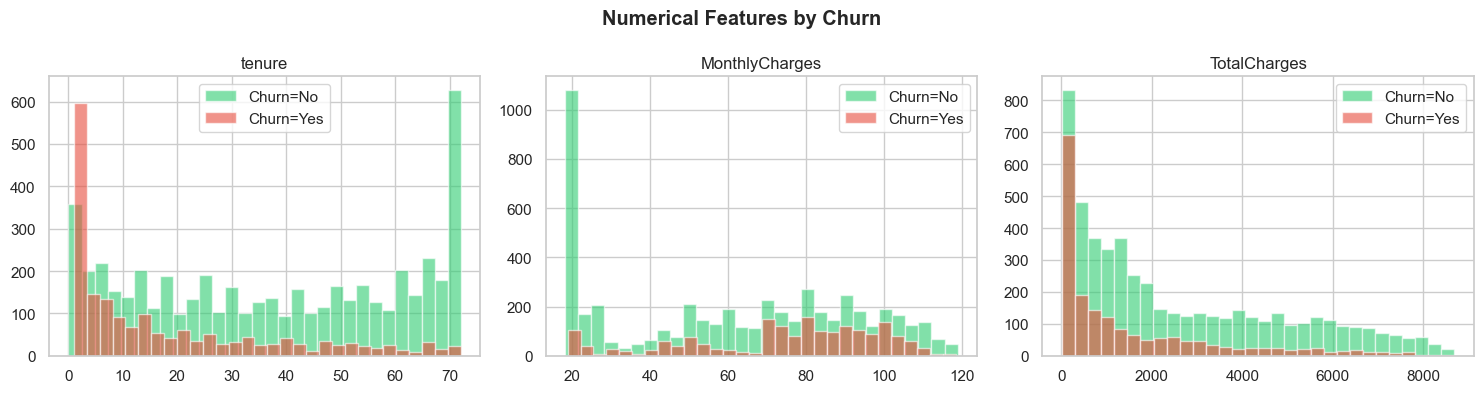

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    for label, color in zip(['No', 'Yes'], ['#2ecc71', '#e74c3c']):
        data = pd.to_numeric(df[df['Churn'] == label][col], errors='coerce').dropna()
        axes[i].hist(data, bins=30, alpha=0.6, color=color, label=f'Churn={label}')
    axes[i].set_title(col)
    axes[i].legend()
plt.suptitle('Numerical Features by Churn', fontweight='bold')
plt.tight_layout()
plt.show()

#### Categorical churn rates

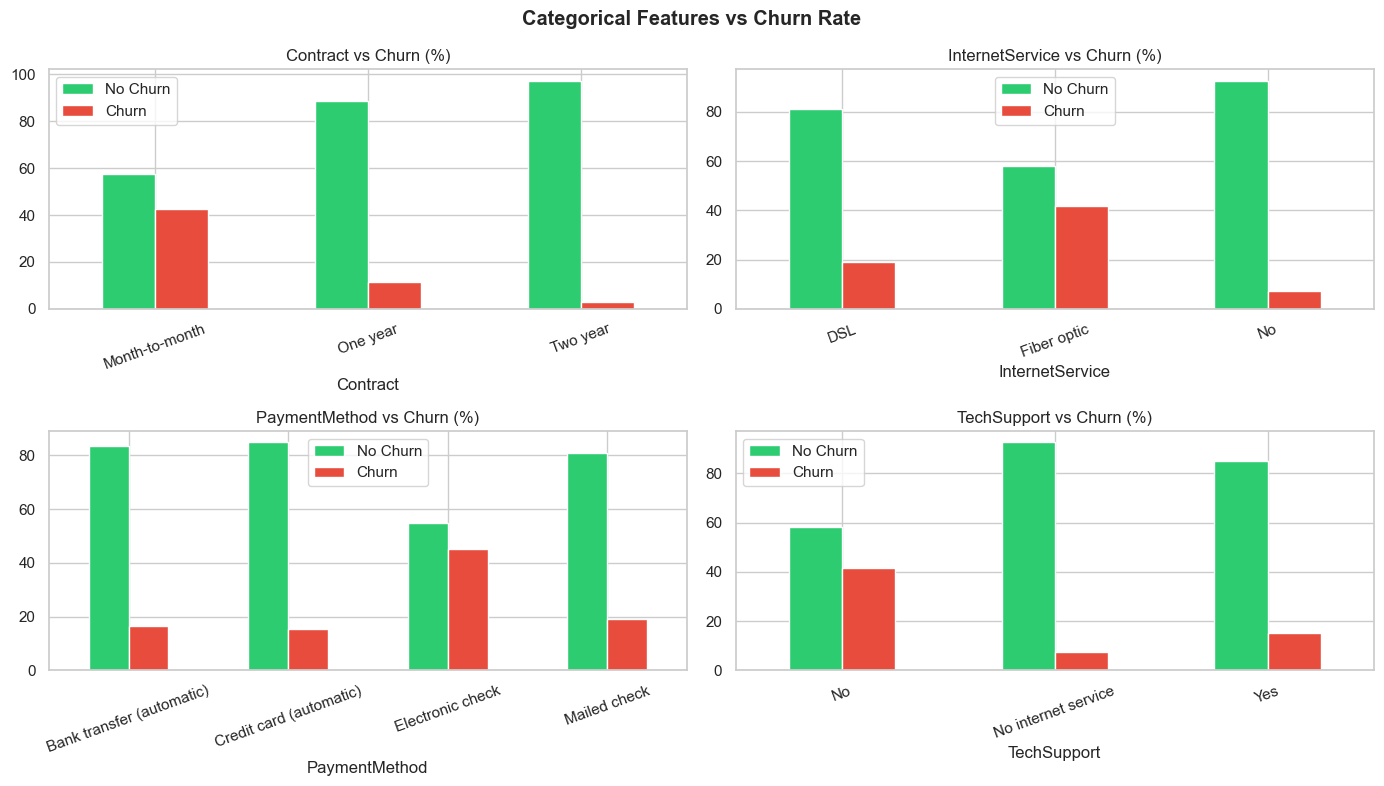

In [37]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'], edgecolor='white')
    axes[i].set_title(f'{col} vs Churn (%)')
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].legend(['No Churn', 'Churn'])
plt.suptitle('Categorical Features vs Churn Rate', fontweight='bold')
plt.tight_layout()
plt.show()

##  Preprocessing

In [38]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.drop(columns=['customerID'], inplace=True)

In [39]:
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

X = df.drop(columns=['Churn'])
y = df['Churn']

#### # Identify column types

In [40]:
numerical_cols   = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical  :", numerical_cols)
print("Categorical:", categorical_cols)

Numerical  : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Train/test split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")


Train: (5634, 19) | Test: (1409, 19)


## Build pipeline

In [42]:
#numerical
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

#categorical
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Combine both transformers into one ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numerical_transformer,   numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1))
])


## GridSearchCV Tuning

In [43]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression Grid
lr_param_grid = {
    'classifier__C':       [0.01, 0.1, 1.0, 10.0],
    'classifier__solver':  ['liblinear', 'lbfgs'],
    'classifier__penalty': ['l2']
}

lr_grid = GridSearchCV(lr_pipeline, lr_param_grid,
                       cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)
lr_grid.fit(X_train, y_train)

print("Best LR Params  :", lr_grid.best_params_)
print("Best LR CV AUC  :", round(lr_grid.best_score_, 4))

#Random Forest Grid
rf_param_grid = {
    'classifier__n_estimators':    [100, 200],
    'classifier__max_depth':       [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__max_features':    ['sqrt', 'log2']
}

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid,
                       cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

print("\nBest RF Params  :", rf_grid.best_params_)
print("Best RF CV AUC  :", round(rf_grid.best_score_, 4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best LR Params  : {'classifier__C': 10.0, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best LR CV AUC  : 0.8462
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best RF Params  : {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best RF CV AUC  : 0.8447


## Evalution

In [44]:
def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'AUC-ROC':   roc_auc_score(y_test, y_prob)
    }, y_pred, y_prob

lr_metrics, lr_pred, lr_prob = evaluate('Logistic Regression', lr_grid.best_estimator_, X_test, y_test)
rf_metrics, rf_pred, rf_prob = evaluate('Random Forest',       rf_grid.best_estimator_, X_test, y_test)

results = pd.DataFrame([lr_metrics, rf_metrics]).set_index('Model')
print(results.round(4))

print("\nLR Classification Report")
print(classification_report(y_test, lr_pred, target_names=['No Churn','Churn']))
print("RF Classification Report")
print(classification_report(y_test, rf_pred, target_names=['No Churn','Churn']))

                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Logistic Regression    0.7381     0.5043  0.7834    0.6136   0.8407
Random Forest          0.7679     0.5464  0.7406    0.6288   0.8396

LR Classification Report
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

RF Classification Report
              precision    recall  f1-score   support

    No Churn       0.89      0.78      0.83      1035
       Churn       0.55      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



## Visualization

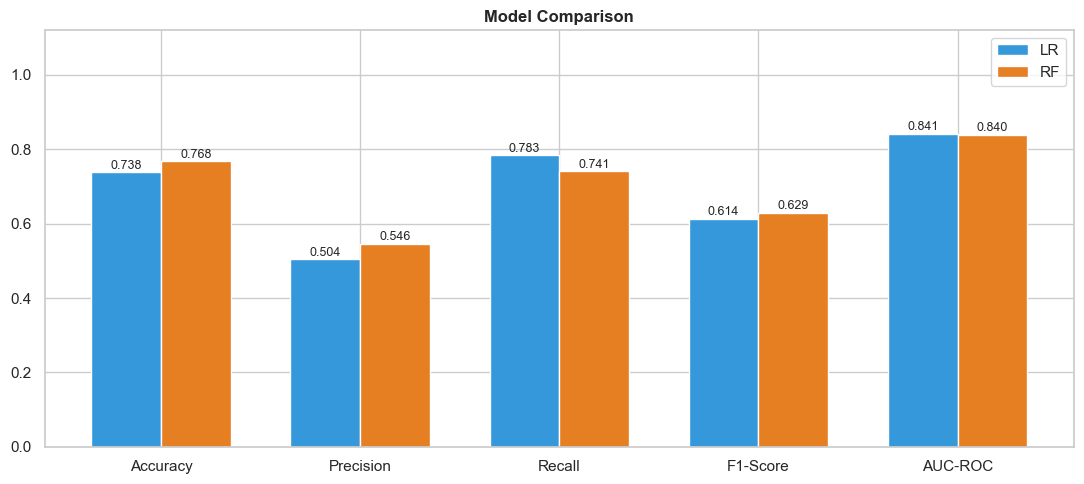

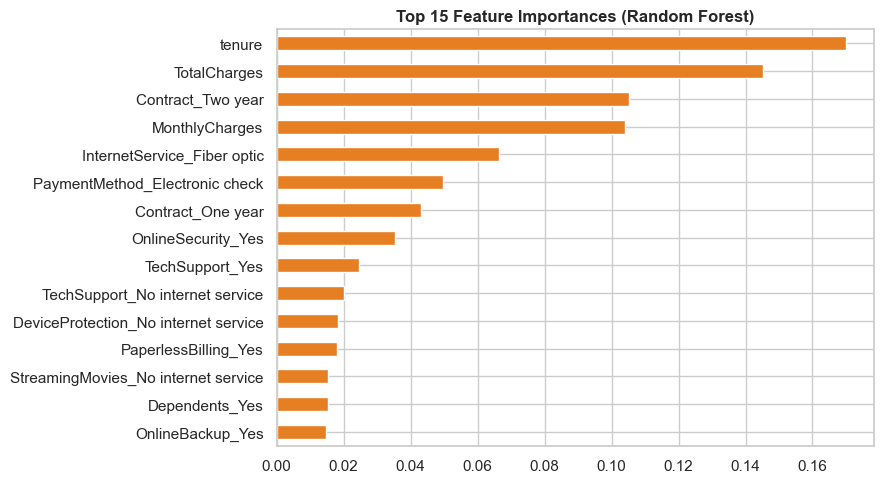

In [45]:
# Metrics bar chart 
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metrics))
w = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, results.iloc[0][metrics], w, label='LR',  color='#3498db', edgecolor='white')
b2 = ax.bar(x + w/2, results.iloc[1][metrics], w, label='RF',  color='#e67e22', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(metrics); ax.set_ylim(0, 1.12)
ax.set_title('Model Comparison', fontweight='bold'); ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

#Feature importances (RF only)
rf_best = rf_grid.best_estimator_
ohe_features = (rf_best.named_steps['preprocessor']
                .named_transformers_['cat']
                .named_steps['onehot']
                .get_feature_names_out(categorical_cols).tolist())
all_features = numerical_cols + ohe_features

importances = pd.Series(rf_best.named_steps['classifier'].feature_importances_,
                        index=all_features).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
importances.sort_values().plot(kind='barh', ax=ax, color='#e67e22', edgecolor='white')
ax.set_title('Top 15 Feature Importances (Random Forest)', fontweight='bold')
plt.tight_layout(); plt.show()

In [46]:
# Pick the better model based on AUC-ROC
best_model = rf_grid.best_estimator_ if rf_metrics['AUC-ROC'] >= lr_metrics['AUC-ROC'] \
             else lr_grid.best_estimator_

# Save full pipeline
joblib.dump(best_model, 'churn_pipeline.joblib')
print("Pipeline saved as churn_pipeline.joblib")

# How to reload and use later
loaded = joblib.load('churn_pipeline.joblib')
sample = X_test.iloc[[0]]
prob   = loaded.predict_proba(sample)[0][1]
print(f"Churn probability: {prob:.4f} {'CHURN' if prob >= 0.5 else 'NO CHURN'}")

Pipeline saved as churn_pipeline.joblib
Churn probability: 0.1211 NO CHURN


## Final Summary & Insights
- Logistic Regression slightly outperformed Random Forest (AUC: 0.8462 vs 0.8447)
- Top churn predictors: Contract type, Tenure, and Monthly Charges
- Month-to-month customers and new users (0–12 months) are highest risk
- Exported pipeline is leakage-free and production-ready